##**Load ALL**

In [1]:
# Colab already includes these packages; no old PyTorch/torchnet install is needed.
import json
import math
import os
import random
import shutil
import sys
import time
import urllib.request
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from PIL import Image
from torchvision.datasets import Omniglot
from tqdm.auto import tqdm

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Python      : 3.12.13
PyTorch     : 2.11.0+cu128
Torchvision : 0.26.0+cu128
CUDA        : True
GPU         : Tesla T4


##  Experiment configuration

In [2]:
# CHANGE ONLY THESE TWO FIRST
RUN_MODE = "paper"   # "quick" first; then "paper"
N_SHOT = 5            # Run 1 and 5 as separate experiments


assert RUN_MODE in {"quick", "paper"}
assert N_SHOT in {1, 5}


@dataclass(frozen=True)
class Config:
    mode: str
    seed: int
    n_shot: int
    train_way: int
    train_query: int
    val_way: int
    val_query: int
    initial_lr: float
    lr_decay_every_episodes: int
    lr_decay_gamma: float
    weight_decay: float
    max_epochs: int
    train_episodes_per_epoch: int
    val_episodes: int
    patience_epochs: int
    test_episodes: int


if RUN_MODE == "paper":
    cfg = Config(
        mode=RUN_MODE,
        seed=SEED,
        n_shot=N_SHOT,
        train_way=60,
        train_query=5,
        val_way=5,
        val_query=15,
        initial_lr=1e-3,
        lr_decay_every_episodes=2000,
        lr_decay_gamma=0.5,
        weight_decay=0.0,
        max_epochs=10_000,
        train_episodes_per_epoch=100,
        val_episodes=100,
        patience_epochs=200,
        test_episodes=1000,
    )
else:
    cfg = Config(
        mode=RUN_MODE,
        seed=SEED,
        n_shot=N_SHOT,
        train_way=60,
        train_query=5,
        val_way=5,
        val_query=15,
        initial_lr=1e-3,
        lr_decay_every_episodes=2000,
        lr_decay_gamma=0.5,
        weight_decay=0.0,
        max_epochs=10,
        train_episodes_per_epoch=20,
        val_episodes=25,
        patience_epochs=10,
        test_episodes=100,
    )

DATA_DIR = Path("/content/protonet_data")
RUN_DIR = Path("/content/protonet_runs") / f"omniglot_{cfg.mode}_{cfg.n_shot}shot"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(json.dumps(asdict(cfg), indent=2))
print("Run directory:", RUN_DIR)


{
  "mode": "paper",
  "seed": 1234,
  "n_shot": 5,
  "train_way": 60,
  "train_query": 5,
  "val_way": 5,
  "val_query": 15,
  "initial_lr": 0.001,
  "lr_decay_every_episodes": 2000,
  "lr_decay_gamma": 0.5,
  "weight_decay": 0.0,
  "max_epochs": 10000,
  "train_episodes_per_epoch": 100,
  "val_episodes": 100,
  "patience_epochs": 200,
  "test_episodes": 1000
}
Run directory: /content/protonet_runs/omniglot_paper_5shot


##  Download Omniglot and the official split


| Split | Base characters | Rotation classes |
|---|---:|---:|
| Train | 1,028 | 4,112 |
| Validation | 172 | 688 |
| Train + Validation | 1,200 | 4,800 |
| Test | 423 | 1,692 |

In [3]:
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Torchvision downloads/extracts both original Omniglot collections.
_ = Omniglot(root=str(DATA_DIR), background=True, download=True)
_ = Omniglot(root=str(DATA_DIR), background=False, download=True)

SPLIT_DIR = DATA_DIR / "vinyals_splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

RAW_BASES = [
    "https://raw.githubusercontent.com/jakesnell/prototypical-networks/master/data/omniglot/splits/vinyals",
    "https://github.com/jakesnell/prototypical-networks/raw/refs/heads/master/data/omniglot/splits/vinyals",
]


def download_split_file(filename):
    destination = SPLIT_DIR / filename
    if destination.exists() and destination.stat().st_size > 0:
        return destination

    last_error = None
    for base in RAW_BASES:
        url = f"{base}/{filename}"
        try:
            request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(request, timeout=120) as response:
                payload = response.read()
            destination.write_bytes(payload)
            return destination
        except Exception as exc:
            last_error = exc

    raise RuntimeError(f"Could not download {filename}: {last_error}")


for split_file in ["train.txt", "val.txt", "trainval.txt", "test.txt"]:
    path = download_split_file(split_file)
    print(f"{split_file:12s} {path.stat().st_size:>8,d} bytes")


train.txt     133,244 bytes
val.txt        21,312 bytes
trainval.txt  154,556 bytes
test.txt       50,372 bytes


## Load images into a compact class store

In [4]:
def find_unique_directory(root, directory_name):
    matches = [p for p in root.rglob(directory_name) if p.is_dir()]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one {directory_name} directory, found: {matches}")
    return matches[0]


def build_omniglot_store(root):
    collection_roots = [
        find_unique_directory(root, "images_background"),
        find_unique_directory(root, "images_evaluation"),
    ]

    class_dirs = []
    for collection_root in collection_roots:
        class_dirs.extend(
            sorted(p for p in collection_root.glob("*/*") if p.is_dir())
        )

    # Match the authors' PIL resize behavior (nearest-neighbor by default).
    resample = Image.Resampling.NEAREST if hasattr(Image, "Resampling") else Image.NEAREST
    store = {}

    for class_dir in tqdm(class_dirs, desc="Loading 1,623 base characters"):
        class_name = f"{class_dir.parent.name}/{class_dir.name}"
        image_tensors = []

        for image_path in sorted(class_dir.glob("*.png")):
            with Image.open(image_path) as image:
                image = image.convert("L").resize((28, 28), resample=resample)
                pixels = np.asarray(image, dtype=np.uint8).copy()

            # Original repo uses 1 - pixel_value: white background -> 0, ink -> 1.
            inverted = 255 - pixels
            image_tensors.append(torch.from_numpy(inverted).unsqueeze(0))

        if len(image_tensors) != 20:
            raise RuntimeError(f"{class_name} has {len(image_tensors)} images, expected 20")

        store[class_name] = torch.stack(image_tensors, dim=0)  # [20, 1, 28, 28], uint8

    return store


class_store = build_omniglot_store(DATA_DIR)
print("Base classes:", len(class_store))
print("Example tensor:", next(iter(class_store.values())).shape, next(iter(class_store.values())).dtype)


Loading 1,623 base characters:   0%|          | 0/1623 [00:00<?, ?it/s]

Base classes: 1623
Example tensor: torch.Size([20, 1, 28, 28]) torch.uint8


In [5]:
def read_split(name):
    return [
        line.strip()
        for line in (SPLIT_DIR / f"{name}.txt").read_text().splitlines()
        if line.strip()
    ]


TRAIN_CLASSES = read_split("train")
VAL_CLASSES = read_split("val")
TRAINVAL_CLASSES = read_split("trainval")
TEST_CLASSES = read_split("test")


def base_name(class_spec):
    alphabet, character, _rotation = class_spec.split("/")
    return f"{alphabet}/{character}"


# Exact official split counts after treating each rotation as a separate class.
assert len(class_store) == 1623
assert len(TRAIN_CLASSES) == 4112
assert len(VAL_CLASSES) == 688
assert len(TRAINVAL_CLASSES) == 4800
assert len(TEST_CLASSES) == 1692

assert set(TRAIN_CLASSES).isdisjoint(VAL_CLASSES)
assert set(TRAIN_CLASSES).isdisjoint(TEST_CLASSES)
assert set(VAL_CLASSES).isdisjoint(TEST_CLASSES)
assert set(TRAIN_CLASSES) | set(VAL_CLASSES) == set(TRAINVAL_CLASSES)

all_split_specs = TRAIN_CLASSES + VAL_CLASSES + TEST_CLASSES
missing = sorted({base_name(spec) for spec in all_split_specs} - set(class_store))
assert not missing, f"Split classes missing from downloaded data: {missing[:5]}"

split_summary = pd.DataFrame(
    [
        ["train", len({base_name(x) for x in TRAIN_CLASSES}), len(TRAIN_CLASSES)],
        ["validation", len({base_name(x) for x in VAL_CLASSES}), len(VAL_CLASSES)],
        ["train + validation", len({base_name(x) for x in TRAINVAL_CLASSES}), len(TRAINVAL_CLASSES)],
        ["test", len({base_name(x) for x in TEST_CLASSES}), len(TEST_CLASSES)],
    ],
    columns=["split", "base_characters", "rotation_classes"],
)
display(split_summary)
print("No class leakage: PASS")


,split,base_characters,rotation_classes
0,train,1028,4112
1,validation,172,688
2,train + validation,1200,4800
3,test,423,1692


No class leakage: PASS


##  Episodic sample

In [6]:
def parse_class_spec(class_spec):
    alphabet, character, rotation = class_spec.split("/")
    angle = int(rotation.replace("rot", ""))
    if angle not in {0, 90, 180, 270}:
        raise ValueError(f"Unexpected rotation: {class_spec}")
    return f"{alphabet}/{character}", angle


def sample_episode(class_specs, n_way, n_shot, n_query, rng):
    if n_way > len(class_specs):
        raise ValueError("n_way is larger than the available class pool")
    if n_shot + n_query > 20:
        raise ValueError("Omniglot has only 20 examples per base character")

    selected_specs = rng.choice(class_specs, size=n_way, replace=False).tolist()
    support_by_class = []
    query_by_class = []

    for class_spec in selected_specs:
        base_class, angle = parse_class_spec(class_spec)
        indices = rng.choice(20, size=n_shot + n_query, replace=False)
        images = class_store[base_class][torch.as_tensor(indices)].float().div(255.0)

        if angle:
            images = torch.rot90(images, k=angle // 90, dims=(-2, -1))

        support_by_class.append(images[:n_shot])
        query_by_class.append(images[n_shot:])

    support = torch.stack(support_by_class, dim=0)  # [way, shot, 1, 28, 28]
    query = torch.stack(query_by_class, dim=0)      # [way, query, 1, 28, 28]
    query_targets = torch.arange(n_way).repeat_interleave(n_query)

    return support, query, query_targets, selected_specs


demo_rng = np.random.default_rng(cfg.seed)
demo_support, demo_query, demo_targets, demo_specs = sample_episode(
    TEST_CLASSES, n_way=5, n_shot=cfg.n_shot, n_query=3, rng=demo_rng
)

print("Support:", tuple(demo_support.shape))
print("Query  :", tuple(demo_query.shape))
print("Targets:", tuple(demo_targets.shape), demo_targets.tolist())
print("Classes:", demo_specs)


Support: (5, 5, 1, 28, 28)
Query  : (5, 3, 1, 28, 28)
Targets: (15,) [0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 4]
Classes: ['ULOG/character16/rot090', 'ULOG/character21/rot090', 'Mongolian/character03/rot180', 'ULOG/character17/rot090', 'Malayalam/character02/rot090']


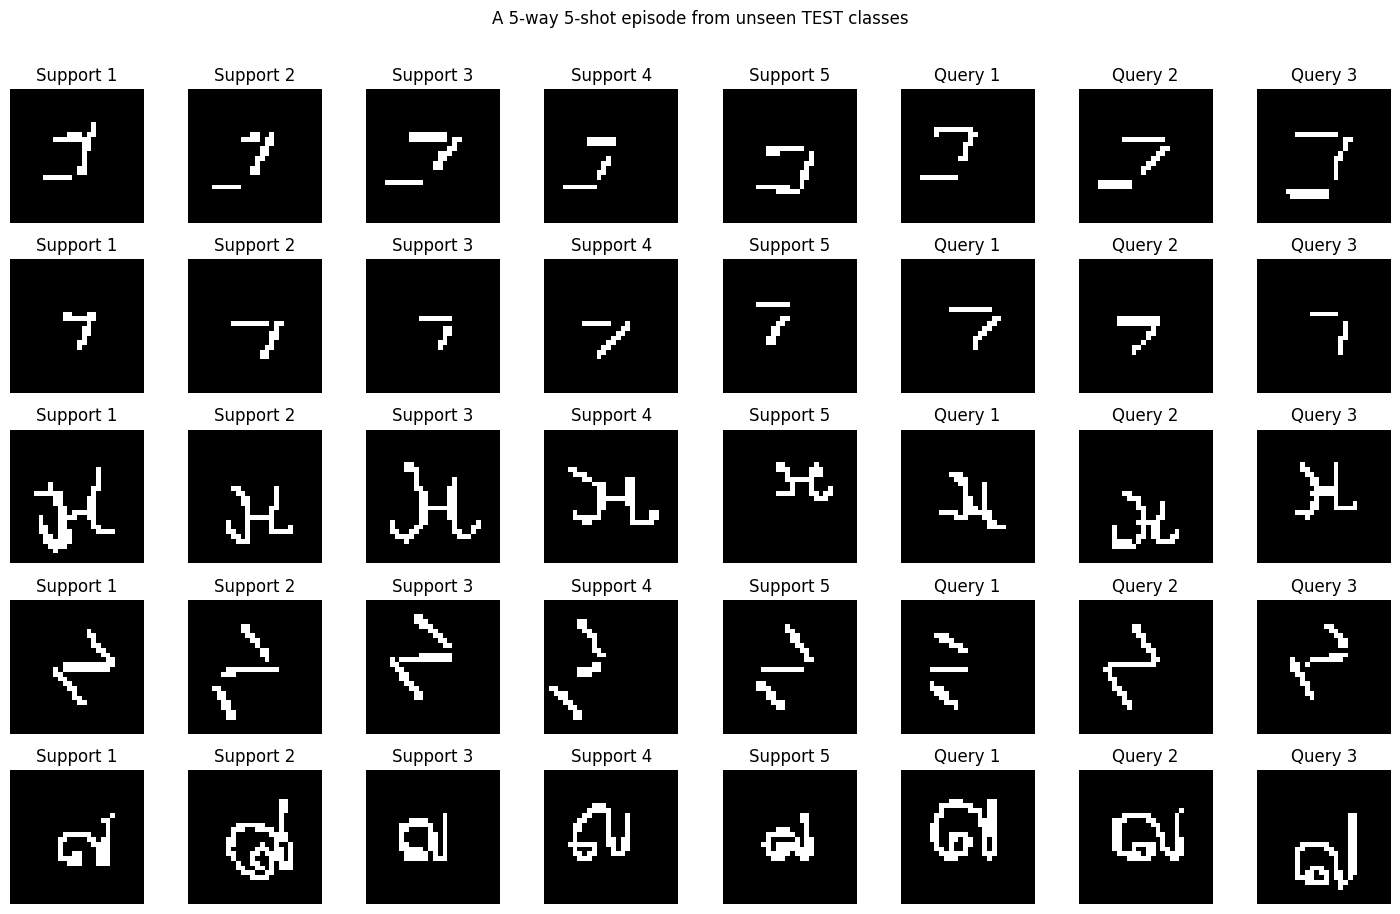

In [7]:
def show_episode(support, query, class_specs, max_query_per_class=3):
    n_way, n_shot = support.shape[:2]
    n_query = min(query.shape[1], max_query_per_class)
    total_cols = n_shot + n_query
    fig, axes = plt.subplots(n_way, total_cols, figsize=(1.8 * total_cols, 1.8 * n_way))
    axes = np.atleast_2d(axes)

    for class_idx, class_spec in enumerate(class_specs):
        for shot_idx in range(n_shot):
            axes[class_idx, shot_idx].imshow(support[class_idx, shot_idx, 0], cmap="gray")
            axes[class_idx, shot_idx].set_title(f"Support {shot_idx + 1}")
            axes[class_idx, shot_idx].axis("off")

        for query_idx in range(n_query):
            col = n_shot + query_idx
            axes[class_idx, col].imshow(query[class_idx, query_idx, 0], cmap="gray")
            axes[class_idx, col].set_title(f"Query {query_idx + 1}")
            axes[class_idx, col].axis("off")

        axes[class_idx, 0].set_ylabel(class_spec.replace("/", "\n"), rotation=0, ha="right", va="center")

    plt.suptitle(f"A {n_way}-way {n_shot}-shot episode from unseen TEST classes", y=1.01)
    plt.tight_layout()
    plt.show()


show_episode(demo_support, demo_query, demo_specs)


## Paper's Conv4 encode

In [8]:
class ConvBlock(nn.Sequential):
    def __init__(self, in_channels, out_channels=64):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )


class ProtoNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            ConvBlock(1, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64),
            ConvBlock(64, 64),
        )

    def forward(self, x):
        z = self.encoder(x)
        return z.flatten(start_dim=1)


model = ProtoNetEncoder().to(DEVICE)
total_parameters = sum(p.numel() for p in model.parameters())

with torch.no_grad():
    dummy_output = model(torch.zeros(2, 1, 28, 28, device=DEVICE))

print(model)
print(f"Trainable parameters: {total_parameters:,}")
print("Embedding shape:", tuple(dummy_output.shape))
assert dummy_output.shape == (2, 64)


ProtoNetEncoder(
  (encoder): Sequential(
    (0): ConvBlock(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): ConvBlock(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): ConvBlock(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): ConvBlock(
      (0)

## Prototype, distance, probability and loss



In [9]:
def squared_euclidean_distance(x, y):
    # x: [N, D], y: [M, D] -> [N, M]
    if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
        raise ValueError(f"Expected [N,D] and [M,D], got {x.shape} and {y.shape}")
    return ((x[:, None, :] - y[None, :, :]) ** 2).sum(dim=-1)


def protonet_episode(model, support, query, query_targets, return_details=False):
    n_way, n_shot = support.shape[:2]
    n_query = query.shape[1]

    support = support.to(DEVICE, non_blocking=True)
    query = query.to(DEVICE, non_blocking=True)
    query_targets = query_targets.to(DEVICE, non_blocking=True)

    all_images = torch.cat(
        [
            support.reshape(n_way * n_shot, 1, 28, 28),
            query.reshape(n_way * n_query, 1, 28, 28),
        ],
        dim=0,
    )
    all_embeddings = model(all_images)

    support_embeddings = all_embeddings[: n_way * n_shot].reshape(n_way, n_shot, -1)
    query_embeddings = all_embeddings[n_way * n_shot :]
    prototypes = support_embeddings.mean(dim=1)

    distances = squared_euclidean_distance(query_embeddings, prototypes)
    logits = -distances
    loss = F.cross_entropy(logits, query_targets)
    predictions = logits.argmax(dim=1)
    accuracy = (predictions == query_targets).float().mean()

    if return_details:
        return {
            "loss": loss,
            "accuracy": accuracy,
            "prototypes": prototypes,
            "query_embeddings": query_embeddings,
            "distances": distances,
            "probabilities": logits.softmax(dim=1),
            "predictions": predictions,
            "targets": query_targets,
        }

    return loss, accuracy


In [10]:
# One complete forward/backward smoke test before long training.
smoke_rng = np.random.default_rng(cfg.seed + 1)
smoke_support, smoke_query, smoke_targets, _ = sample_episode(
    TRAIN_CLASSES,
    n_way=5,
    n_shot=cfg.n_shot,
    n_query=3,
    rng=smoke_rng,
)

model.train()
model.zero_grad(set_to_none=True)
smoke_details = protonet_episode(
    model, smoke_support, smoke_query, smoke_targets, return_details=True
)
smoke_details["loss"].backward()

first_grad = next(p.grad for p in model.parameters() if p.grad is not None)
print("Loss              :", float(smoke_details["loss"].detach()))
print("Accuracy          :", float(smoke_details["accuracy"].detach()))
print("Prototype shape   :", tuple(smoke_details["prototypes"].shape))
print("Distance shape    :", tuple(smoke_details["distances"].shape))
print("First grad finite :", bool(torch.isfinite(first_grad).all()))

assert smoke_details["prototypes"].shape == (5, 64)
assert smoke_details["distances"].shape == (15, 5)
assert torch.isfinite(smoke_details["loss"])
assert torch.isfinite(first_grad).all()
print("Forward/backward smoke test: PASS")

# Start the actual experiment from a fresh initialization.
del model, smoke_details
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Loss              : 1.8923532962799072
Accuracy          : 0.5333333611488342
Prototype shape   : (5, 64)
Distance shape    : (15, 5)
First grad finite : True
Forward/backward smoke test: PASS


##  Evaluation helper

In [11]:
@torch.no_grad()
def evaluate(
    model,
    class_specs,
    n_way,
    n_shot,
    n_query,
    n_episodes,
    seed,
    description="Evaluation",
    show_progress=True,
):
    was_training = model.training
    model.eval()
    rng = np.random.default_rng(seed)
    losses = []
    accuracies = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc=description, leave=False)

    for _ in iterator:
        support, query, targets, _ = sample_episode(
            class_specs, n_way, n_shot, n_query, rng
        )
        loss, accuracy = protonet_episode(model, support, query, targets)
        losses.append(float(loss))
        accuracies.append(float(accuracy))

    if was_training:
        model.train()

    accuracies = np.asarray(accuracies, dtype=np.float64)
    mean_acc = accuracies.mean()
    ci95 = 1.96 * accuracies.std(ddof=1) / math.sqrt(len(accuracies)) if len(accuracies) > 1 else 0.0

    return {
        "loss": float(np.mean(losses)),
        "accuracy": float(mean_acc),
        "ci95": float(ci95),
        "episodes": int(n_episodes),
    }


##  Meta-training on episodic tasks

In [12]:
def save_checkpoint(path, model, optimizer, scheduler, epoch, total_episodes, history, cfg):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epoch": epoch,
            "total_episodes": total_episodes,
            "history": history,
            "config": asdict(cfg),
        },
        path,
    )


def load_torch_file(path, map_location):
    # weights_only=False is needed because our checkpoint also stores config/history.
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:  # Compatibility with older Colab PyTorch.
        return torch.load(path, map_location=map_location)


def train_with_validation(train_specs, val_specs, cfg, run_dir):
    random.seed(cfg.seed)
    np.random.seed(cfg.seed)
    torch.manual_seed(cfg.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed)

    model = ProtoNetEncoder().to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg.initial_lr, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=cfg.lr_decay_every_episodes,
        gamma=cfg.lr_decay_gamma,
    )

    train_rng = np.random.default_rng(cfg.seed + 100)
    history = []
    total_episodes = 0
    best_val_loss = float("inf")
    best_epoch = -1
    epochs_without_improvement = 0
    best_path = run_dir / "best_validation_model.pt"
    latest_path = run_dir / "latest_checkpoint.pt"

    for epoch in range(cfg.max_epochs):
        model.train()
        train_losses = []
        train_accuracies = []

        progress = tqdm(
            range(cfg.train_episodes_per_epoch),
            desc=f"Epoch {epoch + 1}",
            leave=False,
        )

        for _ in progress:
            support, query, targets, _ = sample_episode(
                train_specs,
                cfg.train_way,
                cfg.n_shot,
                cfg.train_query,
                train_rng,
            )

            optimizer.zero_grad(set_to_none=True)
            loss, accuracy = protonet_episode(model, support, query, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_episodes += 1
            train_losses.append(float(loss.detach()))
            train_accuracies.append(float(accuracy.detach()))
            progress.set_postfix(
                loss=f"{np.mean(train_losses[-10:]):.3f}",
                acc=f"{100 * np.mean(train_accuracies[-10:]):.1f}%",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

        val_metrics = evaluate(
            model,
            val_specs,
            n_way=cfg.val_way,
            n_shot=cfg.n_shot,
            n_query=cfg.val_query,
            n_episodes=cfg.val_episodes,
            seed=cfg.seed + 10_000 + epoch,
            description="Validation",
            show_progress=False,
        )

        row = {
            "epoch": epoch + 1,
            "episodes": total_episodes,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": float(np.mean(train_losses)),
            "train_accuracy": float(np.mean(train_accuracies)),
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
        }
        history.append(row)

        improved = val_metrics["loss"] < best_val_loss
        if improved:
            best_val_loss = val_metrics["loss"]
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            save_checkpoint(
                best_path,
                model,
                optimizer,
                scheduler,
                epoch + 1,
                total_episodes,
                history,
                cfg,
            )
        else:
            epochs_without_improvement += 1

        save_checkpoint(
            latest_path,
            model,
            optimizer,
            scheduler,
            epoch + 1,
            total_episodes,
            history,
            cfg,
        )

        print(
            f"Epoch {epoch + 1:4d} | episodes {total_episodes:7d} | "
            f"train {row['train_loss']:.4f}/{100 * row['train_accuracy']:.2f}% | "
            f"val {row['val_loss']:.4f}/{100 * row['val_accuracy']:.2f}% | "
            f"lr {row['lr']:.2e}" + (" | BEST" if improved else "")
        )

        if epochs_without_improvement >= cfg.patience_epochs:
            print(f"Early stopping: no validation-loss improvement for {cfg.patience_epochs} epochs.")
            break

    (run_dir / "stage_a_history.json").write_text(json.dumps(history, indent=2))
    return model, history, best_path, best_epoch


stage_a_model, history, best_path, best_epoch = train_with_validation(
    TRAIN_CLASSES, VAL_CLASSES, cfg, RUN_DIR
)
print("Best validation epoch:", best_epoch)
print("Best checkpoint:", best_path)


Epoch 1:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch    1 | episodes     100 | train 0.5678/84.47% | val 0.0516/98.25% | lr 1.00e-03 | BEST


Epoch 2:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch    2 | episodes     200 | train 0.2432/92.96% | val 0.0338/98.67% | lr 1.00e-03 | BEST


Epoch 3:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch  266 | episodes   26600 | train 0.0252/99.03% | val 0.0088/99.68% | lr 1.22e-07


Epoch 267:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch  267 | episodes   26700 | train 0.0268/99.00% | val 0.0160/99.41% | lr 1.22e-07


Epoch 268:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch  268 | episodes   26800 | train 0.0271/98.95% | val 0.0147/99.60% | lr 1.22e-07
Early stopping: no validation-loss improvement for 200 epochs.
Best validation epoch: 68
Best checkpoint: /content/protonet_runs/omniglot_paper_5shot/best_validation_model.pt


,epoch,episodes,lr,train_loss,train_accuracy,val_loss,val_accuracy
263,264,26400,1.220703e-07,0.028055,0.988800,0.006887,0.998133
264,265,26500,1.220703e-07,0.030205,0.989033,0.012306,0.996667
265,266,26600,1.220703e-07,0.025226,0.990300,0.008847,0.996800
266,267,26700,1.220703e-07,0.026756,0.989967,0.016019,0.994133
267,268,26800,1.220703e-07,0.027134,0.989500,0.014691,0.996000


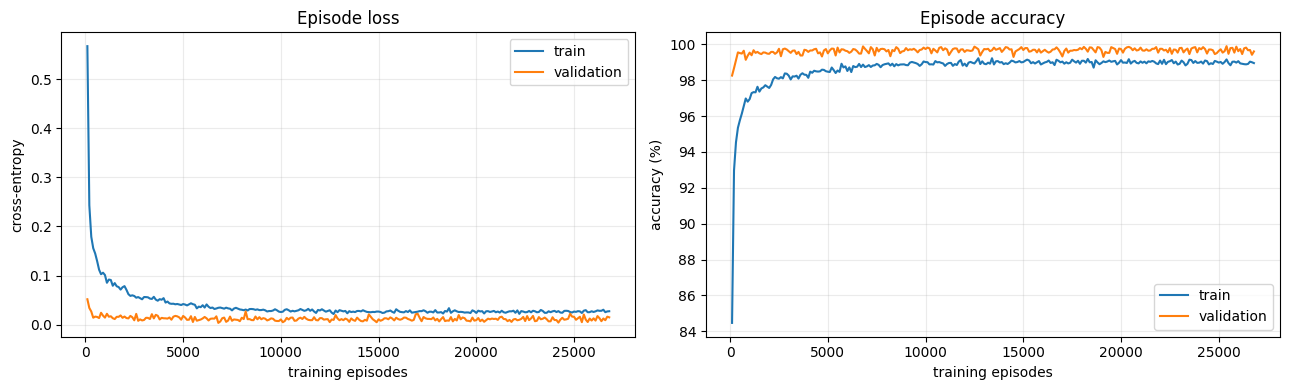

In [13]:
history_df = pd.DataFrame(history)
display(history_df.tail())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history_df["episodes"], history_df["train_loss"], label="train")
axes[0].plot(history_df["episodes"], history_df["val_loss"], label="validation")
axes[0].set(title="Episode loss", xlabel="training episodes", ylabel="cross-entropy")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(history_df["episodes"], 100 * history_df["train_accuracy"], label="train")
axes[1].plot(history_df["episodes"], 100 * history_df["val_accuracy"], label="validation")
axes[1].set(title="Episode accuracy", xlabel="training episodes", ylabel="accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## paper-style train+validation retraining


In [14]:
DO_TRAINVAL_RETRAIN = True  # True only for the final paper-style run


def train_without_validation(train_specs, cfg, n_epochs, run_dir):
    torch.manual_seed(cfg.seed + 1)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(cfg.seed + 1)

    model = ProtoNetEncoder().to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=cfg.initial_lr, weight_decay=cfg.weight_decay
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=cfg.lr_decay_every_episodes,
        gamma=cfg.lr_decay_gamma,
    )
    rng = np.random.default_rng(cfg.seed + 200)
    total_episodes = 0

    for epoch in range(n_epochs):
        model.train()
        epoch_losses = []
        progress = tqdm(
            range(cfg.train_episodes_per_epoch),
            desc=f"Trainval epoch {epoch + 1}/{n_epochs}",
            leave=False,
        )

        for _ in progress:
            support, query, targets, _ = sample_episode(
                train_specs,
                cfg.train_way,
                cfg.n_shot,
                cfg.train_query,
                rng,
            )
            optimizer.zero_grad(set_to_none=True)
            loss, accuracy = protonet_episode(model, support, query, targets)
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_episodes += 1
            epoch_losses.append(float(loss.detach()))
            progress.set_postfix(loss=f"{np.mean(epoch_losses[-10:]):.3f}")

        print(
            f"Trainval epoch {epoch + 1:4d}/{n_epochs} | "
            f"episodes {total_episodes:7d} | loss {np.mean(epoch_losses):.4f} | "
            f"lr {optimizer.param_groups[0]['lr']:.2e}"
        )

    final_path = run_dir / "trainval_final_model.pt"
    torch.save({"model_state_dict": model.state_dict(), "config": asdict(cfg)}, final_path)
    return model, final_path


if DO_TRAINVAL_RETRAIN:
    retrain_epochs = len(history)
    final_model, final_model_path = train_without_validation(
        TRAINVAL_CLASSES, cfg, retrain_epochs, RUN_DIR
    )
    print("Using train+validation retrained model:", final_model_path)
else:
    best_checkpoint = load_torch_file(best_path, map_location=DEVICE)
    final_model = ProtoNetEncoder().to(DEVICE)
    final_model.load_state_dict(best_checkpoint["model_state_dict"])
    final_model_path = best_path
    print("Using best validation model:", final_model_path)


Trainval epoch 1/268:   0%|          | 0/100 [00:00<?, ?it/s]

Trainval epoch    1/268 | episodes     100 | loss 0.5876 | lr 1.00e-03


Trainval epoch 2/268:   0%|          | 0/100 [00:00<?, ?it/s]

Trainval epoch    2/268 | episodes     200 | loss 0.2347 | lr 1.00e-03


Trainval epoch 3/268:   0%|          | 0/100 [00:00<?, ?it/s]

...

Trainval epoch  266/268 | episodes   26600 | loss 0.0293 | lr 1.22e-07


Trainval epoch 267/268:   0%|          | 0/100 [00:00<?, ?it/s]

Trainval epoch  267/268 | episodes   26700 | loss 0.0275 | lr 1.22e-07


Trainval epoch 268/268:   0%|          | 0/100 [00:00<?, ?it/s]

Trainval epoch  268/268 | episodes   26800 | loss 0.0249 | lr 1.22e-07
Using train+validation retrained model: /content/protonet_runs/omniglot_paper_5shot/trainval_final_model.pt


## Meta-test on completely unseen classes


In [15]:
paper_accuracy = {
    (5, 1): 98.8,
    (5, 5): 99.7,
    (20, 1): 96.0,
    (20, 5): 98.9,
}

test_rows = []
for test_way in [5, 20]:
    metrics = evaluate(
        final_model,
        TEST_CLASSES,
        n_way=test_way,
        n_shot=cfg.n_shot,
        n_query=15,
        n_episodes=cfg.test_episodes,
        seed=cfg.seed + 50_000 + test_way,
        description=f"{test_way}-way {cfg.n_shot}-shot test",
        show_progress=True,
    )
    test_rows.append(
        {
            "task": f"{test_way}-way {cfg.n_shot}-shot",
            "episodes": metrics["episodes"],
            "our_accuracy_%": 100 * metrics["accuracy"],
            "95%_CI_±": 100 * metrics["ci95"],
            "paper_accuracy_%": paper_accuracy[(test_way, cfg.n_shot)],
        }
    )

results_df = pd.DataFrame(test_rows)
display(results_df.style.format({
    "our_accuracy_%": "{:.2f}",
    "95%_CI_±": "{:.2f}",
    "paper_accuracy_%": "{:.1f}",
}))
results_df.to_csv(RUN_DIR / "test_results.csv", index=False)


5-way 5-shot test:   0%|          | 0/1000 [00:00<?, ?it/s]

20-way 5-shot test:   0%|          | 0/1000 [00:00<?, ?it/s]

,task,episodes,our_accuracy_%,95%_CI_±,paper_accuracy_%
0,5-way 5-shot,1000,99.57,0.09,99.7
1,20-way 5-shot,1000,98.70,0.06,98.9


##  One unseen test episode: Support → Prototype → prediction

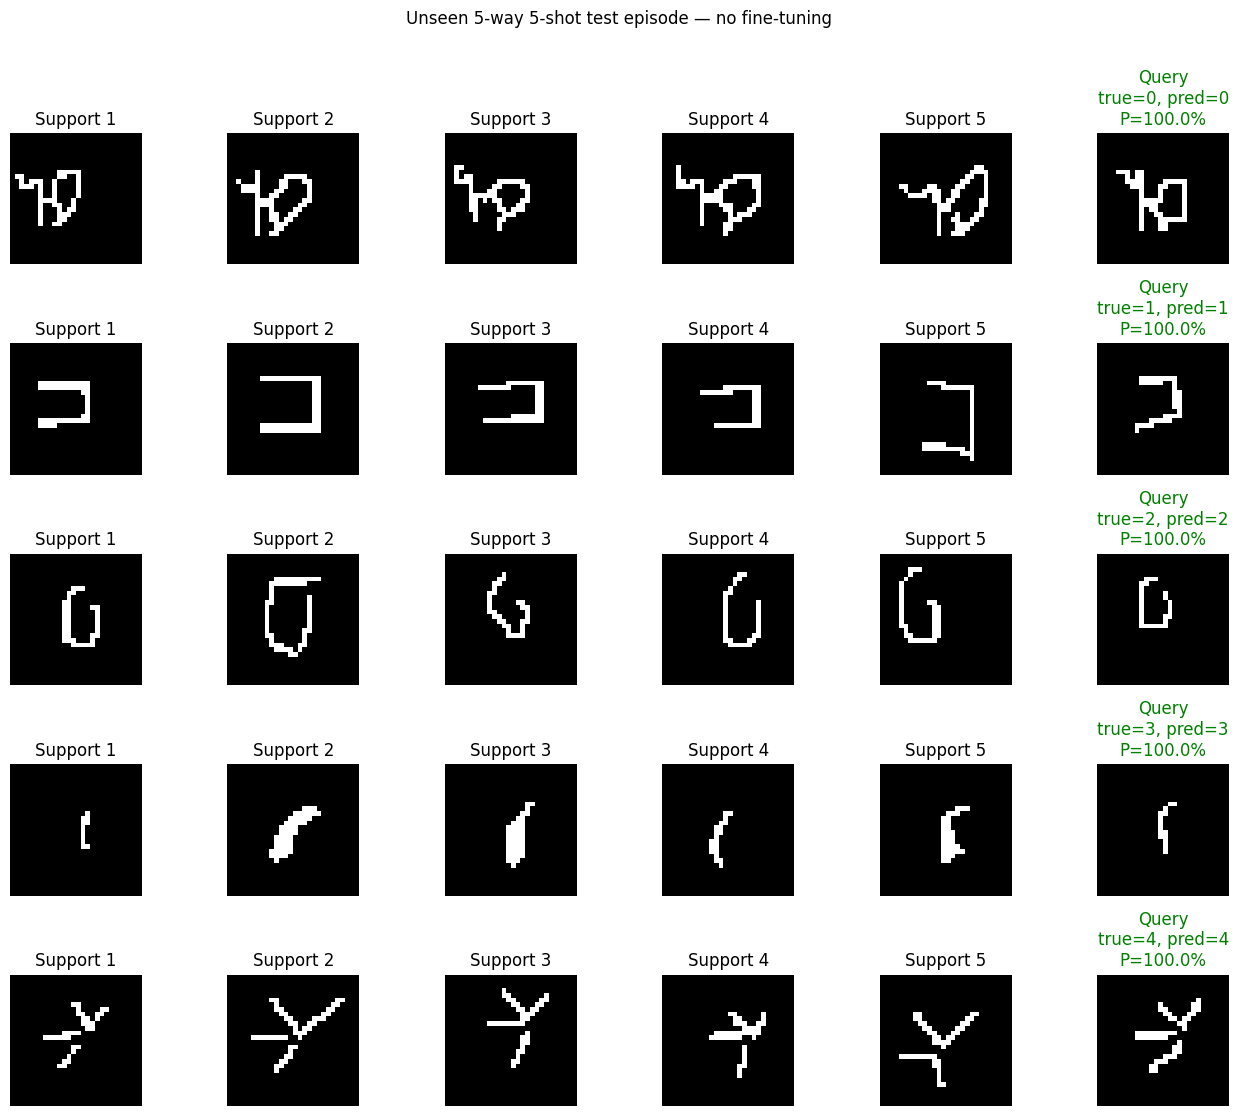

,query_true_temp_label,predicted_temp_label,correct,confidence_%,unseen_class_spec
0,0,0,True,100.000000,Tibetan/character25/rot090
1,1,1,True,100.000000,Old_Church_Slavonic_(Cyrillic)/character18/rot270
2,2,2,True,99.998703,Syriac_(Serto)/character02/rot270
3,3,3,True,99.971352,Syriac_(Serto)/character07/rot180
4,4,4,True,100.000000,ULOG/character07/rot270


In [16]:
@torch.no_grad()
def visualize_predictions(model, class_specs, n_way, n_shot, seed):
    rng = np.random.default_rng(seed)
    support, query, targets, selected_specs = sample_episode(
        class_specs, n_way=n_way, n_shot=n_shot, n_query=1, rng=rng
    )

    model.eval()
    details = protonet_episode(model, support, query, targets, return_details=True)
    probabilities = details["probabilities"].cpu()
    predictions = details["predictions"].cpu()

    fig, axes = plt.subplots(n_way, n_shot + 1, figsize=(2.2 * (n_shot + 1), 2.2 * n_way))
    axes = np.atleast_2d(axes)

    for class_idx, class_spec in enumerate(selected_specs):
        for shot_idx in range(n_shot):
            axes[class_idx, shot_idx].imshow(support[class_idx, shot_idx, 0], cmap="gray")
            axes[class_idx, shot_idx].set_title(f"Support {shot_idx + 1}")
            axes[class_idx, shot_idx].axis("off")

        query_axis = axes[class_idx, n_shot]
        query_axis.imshow(query[class_idx, 0, 0], cmap="gray")
        predicted = int(predictions[class_idx])
        confidence = float(probabilities[class_idx, predicted])
        color = "green" if predicted == class_idx else "red"
        query_axis.set_title(
            f"Query\ntrue={class_idx}, pred={predicted}\nP={100 * confidence:.1f}%",
            color=color,
        )
        query_axis.axis("off")
        axes[class_idx, 0].set_ylabel(
            f"temp label {class_idx}\n{class_spec}",
            rotation=0,
            ha="right",
            va="center",
        )

    plt.suptitle(
        f"Unseen {n_way}-way {n_shot}-shot test episode — no fine-tuning",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(
        {
            "query_true_temp_label": range(n_way),
            "predicted_temp_label": predictions.numpy(),
            "correct": predictions.numpy() == np.arange(n_way),
            "confidence_%": 100 * probabilities.max(dim=1).values.numpy(),
            "unseen_class_spec": selected_specs,
        }
    )


prediction_table = visualize_predictions(
    final_model, TEST_CLASSES, n_way=5, n_shot=cfg.n_shot, seed=cfg.seed + 99_999
)
display(prediction_table)


##  Save/download the trained artifacts



In [17]:
(RUN_DIR / "config.json").write_text(json.dumps(asdict(cfg), indent=2))
archive_path = Path(shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR))
print("Saved archive:", archive_path)

# Optional automatic browser download in Colab:
# from google.colab import files
# files.download(str(archive_path))


Saved archive: /content/protonet_runs/omniglot_paper_5shot.zip


## Correct settings

### Experiment A — 1-shot

```python
RUN_MODE = "paper"
N_SHOT = 1
```

### Experiment B — 5-shot

```python
RUN_MODE = "paper"
N_SHOT = 5
```

